# v03 — Modeling, Feature Importance & Threshold Tuning

범위: baseline 모델 비교, feature importance, threshold tuning.

In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'src' / 'team2_surrender').exists()
)
os.chdir(ROOT)
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from IPython.display import display, Markdown, Image
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from team2_surrender.modeling import FEATURE_COLUMNS, TARGET_COLUMN, GROUP_COLUMN, make_group_split

RUN_ID = 'riot-scale-2600'
DATA_PATH = ROOT / 'data' / 'processed' / 'riot' / f'{RUN_ID}_team_features.csv'
VALIDATION_PATH = ROOT / 'data' / 'processed' / 'riot' / f'{RUN_ID}_team_features_validation_strict.json'
METRICS_PATH = ROOT / 'outputs' / 'metrics' / f'{RUN_ID}_model_comparison.json'
FIGURE_DIR = ROOT / 'reports' / 'figures' / RUN_ID
MODEL_DIR = ROOT / 'models' / RUN_ID
UPLOAD_VERIFICATION_PATH = ROOT / 'outputs' / 'verification' / f'supabase_upload_{RUN_ID}.json'

REQUIRED_PATHS = [DATA_PATH, VALIDATION_PATH, METRICS_PATH, FIGURE_DIR, MODEL_DIR, UPLOAD_VERIFICATION_PATH]

for path in REQUIRED_PATHS:
    print(f'{path.relative_to(ROOT)} -> {path.exists()}')

missing_paths = [path for path in REQUIRED_PATHS if not path.exists()]
if missing_paths:
    missing_text = '\n'.join(str(path.relative_to(ROOT)) for path in missing_paths)
    raise FileNotFoundError(
        'Missing required analysis artifacts:\n'
        f'{missing_text}\n\n'
        'Run: python scripts/prepare_jupyter_analysis_artifacts.py'
    )

data/processed/riot/riot-scale-2600_team_features.csv -> True
data/processed/riot/riot-scale-2600_team_features_validation_strict.json -> True
outputs/metrics/riot-scale-2600_model_comparison.json -> True
reports/figures/riot-scale-2600 -> True
models/riot-scale-2600 -> True
outputs/verification/supabase_upload_riot-scale-2600.json -> True


In [2]:
df = pd.read_csv(DATA_PATH)
y = df[TARGET_COLUMN].astype(bool).astype(int)
print('rows:', len(df))
print('matches:', df[GROUP_COLUMN].nunique())
print('positive rows:', int(y.sum()))
print('positive rate:', round(float(y.mean()), 4))
display(df.head())

rows: 5050
matches: 2525
positive rows: 870
positive rate: 0.1723


,match_id,team_id,feature_version,team_surrendered,queue_id,game_version,game_duration_sec,collected_at,gold_diff_15,kill_diff_15,tower_diff_15,dragon_diff_15,rift_herald_diff_15,cs_diff_15,avg_level_diff_15,first_blood,first_tower,ward_placed_diff_15,ward_kill_diff_15
0,KR_8143703690,100,v1_15min,True,420,16.6.756.931,1382,2026-05-14T19:59:29+00:00,-270,-6,1,-1,0,8,-0.4,1,1,-7,2
1,KR_8143703690,200,v1_15min,False,420,16.6.756.931,1382,2026-05-14T19:59:29+00:00,270,6,-1,1,0,-8,0.4,-1,-1,7,-2
2,KR_8143357958,100,v1_15min,False,420,16.6.756.931,2232,2026-05-14T19:59:29+00:00,2064,3,0,-2,0,9,0.2,-1,-1,1,-2
3,KR_8143357958,200,v1_15min,False,420,16.6.756.931,2232,2026-05-14T19:59:29+00:00,-2064,-3,0,2,0,-9,-0.2,1,1,-1,2
4,KR_8143287893,100,v1_15min,False,420,16.6.756.931,1473,2026-05-14T19:59:29+00:00,-4374,-9,0,-2,0,-74,-0.6,-1,0,1,-6


## 1. Model comparison

In [3]:
metrics = json.loads(METRICS_PATH.read_text())
rows = []
for model_name, splits in metrics['models'].items():
    for split_name, vals in splits.items():
        row = {'model': model_name, 'split': split_name}
        for col in ['accuracy', 'f1', 'precision', 'recall', 'roc_auc', 'pr_auc']:
            row[col] = vals[col]
        rows.append(row)
metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values(['split', 'roc_auc'], ascending=[True, False]))

test_metrics = metrics_df[metrics_df['split'] == 'test'].set_index('model')
display(test_metrics.sort_values('roc_auc', ascending=False))

,model,split,accuracy,f1,precision,recall,roc_auc,pr_auc
4,logistic_regression,test,0.725743,0.493601,0.371901,0.733696,0.810105,0.494369
6,random_forest,test,0.833663,0.408451,0.580000,0.315217,0.785398,0.477138
2,hist_gradient_boosting,test,0.814851,0.304833,0.482353,0.222826,0.745210,0.386331
0,dummy_most_frequent,test,0.817822,0.000000,0.000000,0.000000,0.500000,0.182178
5,logistic_regression,valid,0.725248,0.490826,0.362712,0.758865,0.827586,0.489153
7,random_forest,valid,0.827970,0.398268,0.511111,0.326241,0.806809,0.458417
3,hist_gradient_boosting,valid,0.809406,0.280374,0.410959,0.212766,0.770179,0.408950
1,dummy_most_frequent,valid,0.825495,0.000000,0.000000,0.000000,0.500000,0.174505


,split,accuracy,f1,precision,recall,roc_auc,pr_auc
model,,,,,,,
logistic_regression,test,0.725743,0.493601,0.371901,0.733696,0.810105,0.494369
random_forest,test,0.833663,0.408451,0.580000,0.315217,0.785398,0.477138
hist_gradient_boosting,test,0.814851,0.304833,0.482353,0.222826,0.745210,0.386331
dummy_most_frequent,test,0.817822,0.000000,0.000000,0.000000,0.500000,0.182178


## 2. Test metric plot

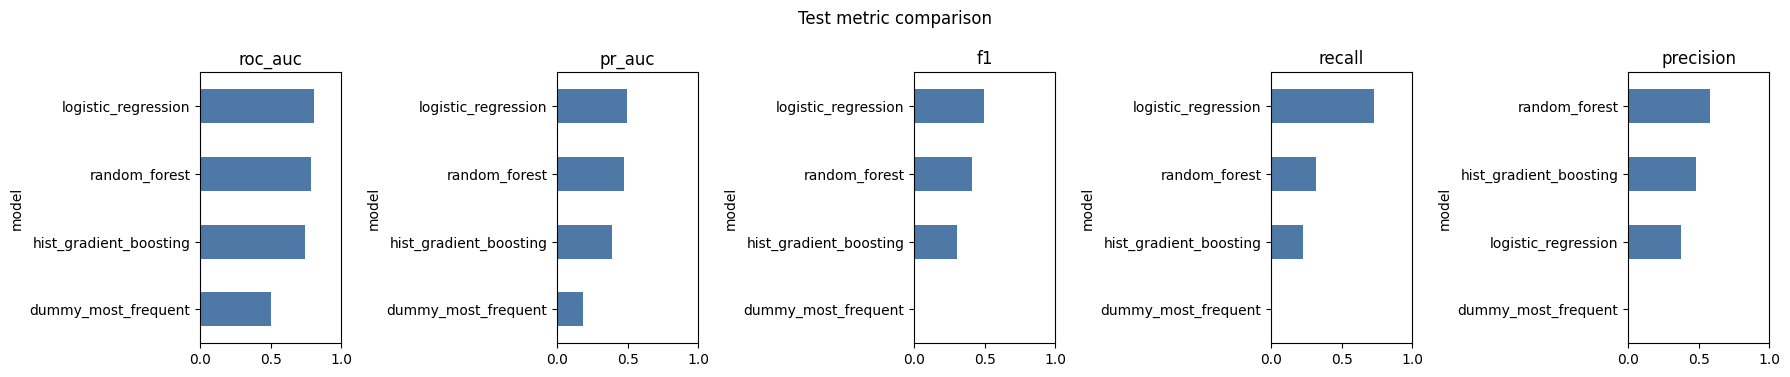

In [4]:
plot_cols = ['roc_auc', 'pr_auc', 'f1', 'recall', 'precision']
fig, axes = plt.subplots(1, len(plot_cols), figsize=(18, 3.8))
for ax, col in zip(axes, plot_cols):
    test_metrics[col].sort_values().plot(kind='barh', ax=ax, color='#4e79a7')
    ax.set_title(col)
    ax.set_xlim(0, 1)
plt.suptitle('Test metric comparison')
plt.tight_layout()
plt.show()

## 3. Feature importance

,feature,logistic_coef,abs_coef
0,gold_diff_15,-0.808950,0.808950
1,kill_diff_15,-0.387276,0.387276
3,dragon_diff_15,-0.220077,0.220077
6,avg_level_diff_15,-0.076985,0.076985
7,first_blood,0.076605,0.076605
10,ward_kill_diff_15,0.062620,0.062620
9,ward_placed_diff_15,0.053085,0.053085
5,cs_diff_15,-0.049336,0.049336
2,tower_diff_15,0.045733,0.045733
8,first_tower,0.028455,0.028455


,feature,rf_importance
0,gold_diff_15,0.248118
5,cs_diff_15,0.148075
1,kill_diff_15,0.142226
9,ward_placed_diff_15,0.106197
6,avg_level_diff_15,0.104389
10,ward_kill_diff_15,0.089567
3,dragon_diff_15,0.059772
2,tower_diff_15,0.055772
8,first_tower,0.025703
7,first_blood,0.020182


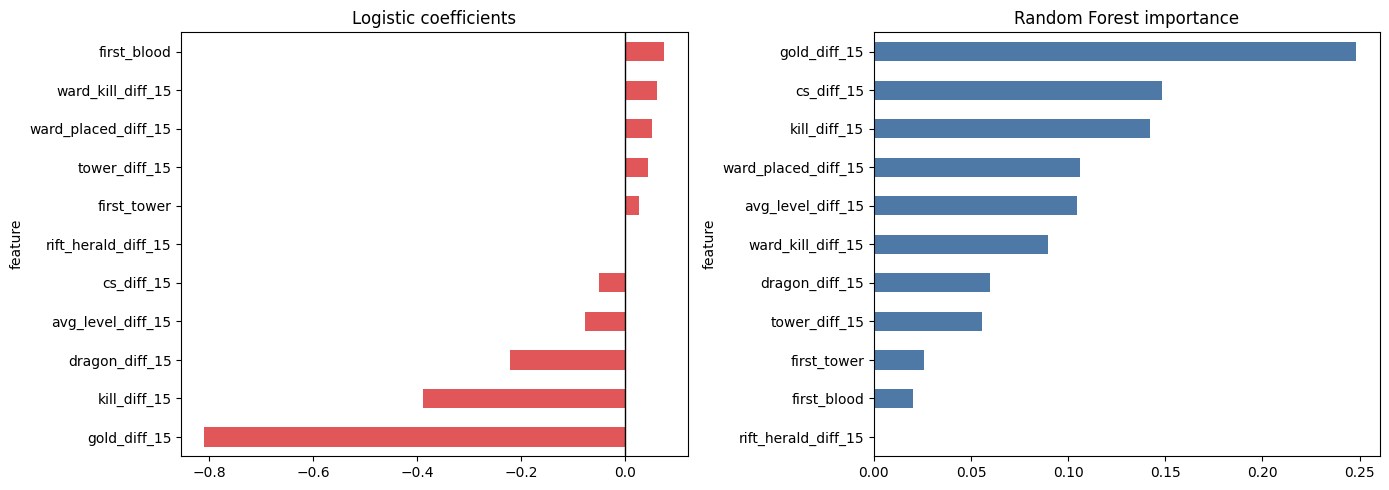

In [5]:
logistic = joblib.load(MODEL_DIR / 'logistic_regression.joblib')
rf = joblib.load(MODEL_DIR / 'random_forest.joblib')

coef_df = pd.DataFrame({'feature': FEATURE_COLUMNS, 'logistic_coef': logistic.named_steps['model'].coef_[0]})
coef_df['abs_coef'] = coef_df['logistic_coef'].abs()
display(coef_df.sort_values('abs_coef', ascending=False))

rf_df = pd.DataFrame({'feature': FEATURE_COLUMNS, 'rf_importance': rf.named_steps['model'].feature_importances_})
display(rf_df.sort_values('rf_importance', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
coef_df.sort_values('logistic_coef').plot(x='feature', y='logistic_coef', kind='barh', ax=axes[0], legend=False, color='#e15759')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Logistic coefficients')
rf_df.sort_values('rf_importance').plot(x='feature', y='rf_importance', kind='barh', ax=axes[1], legend=False, color='#4e79a7')
axes[1].set_title('Random Forest importance')
plt.tight_layout()
plt.show()

## 4. Logistic threshold tuning

,threshold,valid_f1,valid_precision,valid_recall
55,0.60,0.509915,0.424528,0.638298
51,0.56,0.507772,0.400000,0.695035
54,0.59,0.505556,0.415525,0.645390
56,0.61,0.504348,0.426471,0.617021
63,0.68,0.503311,0.472050,0.539007
49,0.54,0.502513,0.389105,0.709220
50,0.55,0.500000,0.390438,0.695035
52,0.57,0.500000,0.397490,0.673759
53,0.58,0.500000,0.402597,0.659574
57,0.62,0.498516,0.428571,0.595745


,selected_threshold,test_f1,test_precision,test_recall,test_confusion_matrix
0,0.6,0.512941,0.452282,0.592391,"[[694, 132], [75, 109]]"


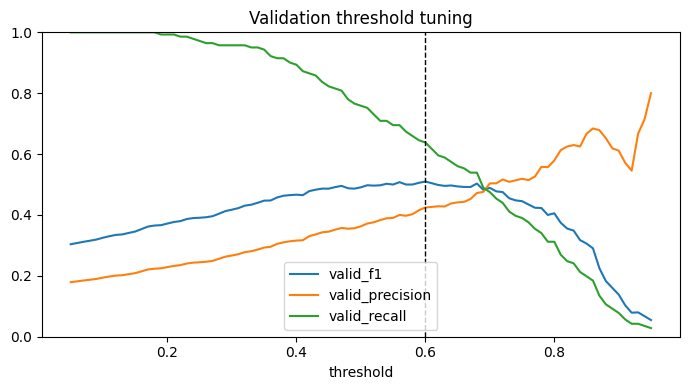

In [6]:
split = make_group_split(df, group_col=GROUP_COLUMN, random_state=42)
X = df[FEATURE_COLUMNS]
valid_idx = split.valid_idx
test_idx = split.test_idx
valid_scores = logistic.predict_proba(X.iloc[valid_idx])[:, 1]
test_scores = logistic.predict_proba(X.iloc[test_idx])[:, 1]

threshold_rows = []
for thr in np.linspace(0.05, 0.95, 91):
    pred = (valid_scores >= thr).astype(int)
    threshold_rows.append({
        'threshold': thr,
        'valid_f1': f1_score(y.iloc[valid_idx], pred, zero_division=0),
        'valid_precision': precision_score(y.iloc[valid_idx], pred, zero_division=0),
        'valid_recall': recall_score(y.iloc[valid_idx], pred, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_rows)
best = threshold_df.sort_values('valid_f1', ascending=False).iloc[0]
display(threshold_df.sort_values('valid_f1', ascending=False).head(10))

test_pred = (test_scores >= best['threshold']).astype(int)
tuned = pd.DataFrame([{
    'selected_threshold': float(best['threshold']),
    'test_f1': f1_score(y.iloc[test_idx], test_pred, zero_division=0),
    'test_precision': precision_score(y.iloc[test_idx], test_pred, zero_division=0),
    'test_recall': recall_score(y.iloc[test_idx], test_pred, zero_division=0),
    'test_confusion_matrix': confusion_matrix(y.iloc[test_idx], test_pred, labels=[0, 1]).tolist(),
}])
display(tuned)

fig, ax = plt.subplots(figsize=(7, 4))
threshold_df.plot(x='threshold', y=['valid_f1', 'valid_precision', 'valid_recall'], ax=ax)
ax.axvline(best['threshold'], color='black', linestyle='--', linewidth=1)
ax.set_title('Validation threshold tuning')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## v03 notes

- Test ROC-AUC 기준 Logistic Regression이 가장 높음.
- class imbalance가 있어 threshold 0.5와 tuned threshold를 함께 기록함.